In [14]:
import os
import pandas as pd
import geopandas as gpd
import scipy.spatial.distance as ssd
import shapely.geometry as sgeom
import math

import networkx as nx
import networkx.algorithms.approximation as nx_app

from pathlib import Path
from functools import partial
from itertools import combinations

In [2]:
os.getcwd()

'/Users/lincoln/geography/massachusetts'

# Data Input

## Home / starting point

In [3]:
home = gpd.tools.geocode(["4 crestwood drive, franklin, ma"])

## Town Halls and Libraries of Massachusetts

In [4]:
townhalls = gpd.read_file('townhalls_pt/TOWNHALLS_PT_MEMA.shp')
libraries = gpd.read_file('libraries/LIBRARIES_PT.shp')

In [5]:
libraries

,NAME,ADDRESS,TOWN,STATE,ZIP,TYPE,ADDRESS_PO,LIBKEY,NETWORK,REGION,DELIVROUTE,WEBSITE,geometry
0,EGREMONT FREE LIBRARY,1 BUTTONBALL LANE,EGREMONT,MA,01230,PUBLIC,M_42081_880811,PU-EGREMONT-FREE,C/WMARS,Western,Optima,http://egremont-ma.gov/,POINT (42080.824 880810.865)
1,FLORIDA FREE PUBLIC LIBRARY,56 NORTH COUNTY ROAD,FLORIDA,MA,01247,PUBLIC,M_73999_939186,PU-FLORIDA-FREE,C/WMARS,Western,Optima,None,POINT (73998.820 939185.588)
2,HOLYOKE PUBLIC LIBRARY,250 CHESTNUT STREET,HOLYOKE,MA,01040,PUBLIC,M_108126_884338,PU-HOLYOKE-PUBLIC,C/WMARS,Western,Optima,http://www.holyokelibrary.org,POINT (108125.885 884337.953)
3,MASON SQUARE BRANCH LIBRARY,765 STATE STREET,SPRINGFIELD,MA,01109,PUBLIC BRANCH,M_111823_873863,PU-SPRINGFI-CITY,C/WMARS,Western,Optima,http://www.springfieldlibrary.org/,POINT (111822.608 873862.592)
4,NORTH ADAMS PUBLIC LIBRARY,74 CHURCH STREET,NORTH ADAMS,MA,01247,PUBLIC,M_68185_939879,PU-NADAMS-PUBLIC,C/WMARS,Western,Optima,http://www.naplibrary.com,POINT (68185.483 939879.244)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
465,MIDDLEFIELD PUBLIC LIBRARY,188 SKYLINE TRAIL,MIDDLEFIELD,MA,01243,PUBLIC,M_75622_900447,PU-MIDDLEFI-PUBLIC,None,Western,Optima,http://middlefieldma.net/?page_id=172,POINT (75613.611 900456.660)
466,GRISWOLD MEMORIAL LIBRARY,12 MAIN ROAD,COLRAIN,MA,01340,PUBLIC,M_101678_936447,PU-COLRAIN-GRISWOLD,C/WMARS,Western,Optima,http://colrain-ma.gov/departments/library.html,POINT (101678.371 936446.501)
467,TYLER MEMORIAL LIBRARY,157 MAIN STREET,CHARLEMONT,MA,01339,PUBLIC,M_87563_931780,PU-CHARLEMO-TYLER,C/WMARS,Western,Optima,http://www.charlemont-ma.us/town/tyler-memoria...,POINT (87563.123 931783.458)
468,WESTHAMPTON PUBLIC LIBRARY,1 NORTH ROAD,WESTHAMPTON,MA,01027,PUBLIC,M_94935_895687,PU-WESTHAMP-MEMORIAL,C/WMARS,Western,Optima,https://www.westhampton-ma.com/westhampton-pub...,POINT (94935.281 895687.373)


## Counties of Massachusetts

In [6]:
counties = gpd.read_file('counties/COUNTIES_POLYM.shp')

In [7]:
counties

,OBJECTID,FIPS_ID,COUNTY,AREA_ACRES,SHAPE_AREA,SHAPE_LEN,geometry
0,2,25003,BERKSHIRE,605697.0,2.451161e+09,247129.554153,"POLYGON ((77140.460 940054.000, 77271.680 9400..."
1,3,25005,BRISTOL,365988.5,1.481121e+09,501028.949137,"MULTIPOLYGON (((241888.920 851747.060, 241922...."
2,4,25007,DUKES,70335.6,2.846304e+08,307054.752491,"MULTIPOLYGON (((275042.500 803927.560, 275096...."
3,5,25009,ESSEX,329540.1,1.333595e+09,624440.032395,"MULTIPOLYGON (((242123.030 912106.690, 242151...."
4,1,25001,BARNSTABLE,263988.0,1.068310e+09,914189.089477,"MULTIPOLYGON (((306542.380 822469.130, 306590...."
5,8,25015,HAMPSHIRE,348972.6,1.412241e+09,279931.716280,"POLYGON ((88528.920 915390.310, 90523.740 9148..."
6,9,25017,MIDDLESEX,541818.4,2.192662e+09,347861.002364,"MULTIPOLYGON (((220529.030 940409.500, 221441...."
7,6,25011,FRANKLIN,463739.8,1.876674e+09,252550.580977,"POLYGON ((135868.310 941518.250, 136724.090 93..."
8,7,25013,HAMPDEN,405796.9,1.642202e+09,274691.442155,"POLYGON ((84999.410 899853.190, 85058.400 8988..."
9,10,25019,NANTUCKET,31378.0,1.269791e+08,147133.860742,"MULTIPOLYGON (((322093.470 793991.190, 322246...."


# Function definitions

Desiderata for robust TSP Solver:
* Decouple the "county" overlay from the rest of it; provide for more general "subsetting" of the "points of interest" tables. 
    * I.e. county overlay is good, but maybe sometimes I have a specific list of towns that I want to restrict my TSP route to, or some other geographic region than a county. 
    * There should be some general way of specifying "restrictions"/subsets of the points of interest tables (here, `townhalls` and `libraries` but potentially other geographic features later)
    * Perhaps even totally decouple these: table of points provided to TSPSolver is used as is, so you can do any subsetting and whatever beforehand. 
    
* Use numerical index as graph node labels and possibly store all dataframe columns as attributes in the graph. This way we can reconstruct the re-ordered points of interest table after TSP, without needing to rely on selecting a "key column" and merging the TSP results back to the original table, as this is redundant. We should just produce a reordered index and reindex the original DF. The current method of picking a "key column" breaks on towns that share library names or any value in the key column. 

In [8]:
class TSPSolver:
    def __init__(
        self,
        points_of_interest: gpd.GeoDataFrame,
        starting_point: gpd.GeoDataFrame,
        tsp_function=None
    ):
        # Ensure we have a clean copy and that each row has a unique index number
        self.points_of_interest = points_of_interest.copy()
                
        if starting_point is not None:
            # Copy the starting point GeoDataFrame and convert the CRS to our point list's CRS
            self.starting_point = starting_point.copy().to_crs(self.points_of_interest.crs)
            self.starting_point = self.starting_point[['geometry']]
            
            self.points_of_interest = pd.concat([self.starting_point, self.points_of_interest])
        
        self.points_of_interest.reset_index(drop=True, inplace=True)
        
        self.graph = nx.Graph()
        
        if callable(tsp_function):
            self.tsp_function = tsp_function
        else: 
            self.tsp_function = nx_app.traveling_salesman_problem
        
        
    def create_pairwise_distance_graph(self):
        geometry_dict = self.points_of_interest.to_dict(orient='index')
        
        for ind1, ind2 in combinations(geometry_dict, 2):
            entry1 = geometry_dict[ind1]
            entry2 = geometry_dict[ind2]
            
            self.graph.add_edge(
                ind1, 
                ind2, 
                weight=entry1['geometry'].distance(entry2['geometry'])
            )
    
    def solve_tsp(self, **kwargs):
        tsp_solution = self.tsp_function(self.graph, **kwargs)
        edge_weights = []
        
        for i in range(len(tsp_solution) - 1):
            n_1 = tsp_solution[i]
            n_2 = tsp_solution[i+1]
            edge_weights.append(self.graph[n_1][n_2]['weight'])
        
        self.tsp_solution = tsp_solution
        self.tsp_edge_weights = edge_weights
        
        self.tsp_results = self.points_of_interest.reindex(self.tsp_solution)
        self.tsp_results['Distance'] = [0] + self.tsp_edge_weights
        self.tsp_results['Cumulative Distance'] = self.tsp_results['Distance'].cumsum()
        
    def make_path(self):
        path_comps = []

        for i in range(len(self.tsp_results) - 1):
            p_1 = self.tsp_results['geometry'].values[i]
            p_2 = self.tsp_results['geometry'].values[i+1]
            path_comps.append({
                'Number': i+1, 
                'geometry': sgeom.LineString((p_1, p_2))
            })
        
        self.tsp_path = gpd.GeoDataFrame(path_comps, crs=self.tsp_results.crs)

In [9]:
def get_county_overlay(counties_df, name, overlay_df, county_column='COUNTY', **overlay_kwargs):
    """
    Returns a GeoDataFrame of geometry objects of overlay_df that are contained 
    in the county geometry for the county whose NAME is name. 
    
    Parameters
    ----------
    counties_df : GeoDataFrame
        GeoDataFrame of county geometries
    name : str
        Name of the county to select
    overlay_df : GeoDataFrame
        GeoDataFrame of geographical features of interest, presumably that have 
        some overlap with the desired county.
    county_column : str
        Column name used in the counties_df to select the right county. In the Massachusetts 
        data that I have, this is 'COUNTY'.
    **overlay_kwargs : Keyword args
        These are passed into geopandas.overlay().
        
    Returns
    -------
    GeoDataFrame or None
        If the specified county name is not found, returns None. 
        Otherwise, GeoDataFrame resulting from performing the overlay operation with the selected 
        county and the overlay_df's objects. This may be empty if no overlap occurs.
    """
    selected_county = counties_df[counties_df['COUNTY']==name.upper()]
    if selected_county.empty:
        raise KeyError(f'County {name} not found in county DataFrame')
    
    return selected_county.overlay(overlay_df, keep_geom_type=False, **overlay_kwargs)[overlay_df.columns]

In [10]:
def get_libraries_in_county(counties_df, name, libraries_df, drop_branch=True):
    county_libraries = get_county_overlay(counties_df, name, libraries_df)
    
    if drop_branch:
        # drop branch libraries
        county_libraries = county_libraries[county_libraries['TYPE'] == 'PUBLIC']
        
    return county_libraries

def get_townhalls_in_county(counties_df, name, townhalls_df):
    county_townhalls = get_county_overlay(counties_df, name, townhalls_df)
    return county_townhalls


def solve_tsp_for_points_in_county(
    counties_df, 
    name, 
    points_df, 
    get_points_func, 
    starting_point=None
):
    county_points = get_points_func(counties_df, name, points_df)
    
    solver = TSPSolver(county_points, starting_point)
    solver.create_pairwise_distance_graph()
    solver.solve_tsp()
    solver.make_path()
        
    return solver

solve_tsp_for_townhalls_in_county = partial(
    solve_tsp_for_points_in_county,
    get_points_func=get_townhalls_in_county
)

solve_tsp_for_libraries_in_county = partial(
    solve_tsp_for_points_in_county,
    get_points_func=get_townhalls_in_county
)

In [11]:
def estimate_divided_distance(results_df, towns_per_trip, starting_point):
    n_results = len(results_df)
    n_trips = math.ceil(n_results / towns_per_trip)
    
    starting_point = starting_point.to_crs(results_df.crs).geometry.values[0]
    
    trip_table = []
    
    for trip_i in range(0, n_results, towns_per_trip):
        trip_slice = results_df.iloc[trip_i:trip_i+towns_per_trip]
        
        trip_start_point = trip_slice['geometry'].values[0]
        trip_end_point = trip_slice['geometry'].values[-1]
        
        start_distance = starting_point.distance(trip_start_point)
        end_distance = starting_point.distance(trip_end_point)
        
        trip_distance = start_distance + end_distance + trip_slice['Distance'].sum()
        
        trip_table.append({
            'start ind': trip_i,
            'end ind': trip_i + towns_per_trip,
            'distance': trip_distance
        })
    
    return pd.DataFrame(trip_table)
    
        

In [22]:
libraries

,NAME,ADDRESS,TOWN,STATE,ZIP,TYPE,ADDRESS_PO,LIBKEY,NETWORK,REGION,DELIVROUTE,WEBSITE,geometry
0,EGREMONT FREE LIBRARY,1 BUTTONBALL LANE,EGREMONT,MA,01230,PUBLIC,M_42081_880811,PU-EGREMONT-FREE,C/WMARS,Western,Optima,http://egremont-ma.gov/,POINT (42080.824 880810.865)
1,FLORIDA FREE PUBLIC LIBRARY,56 NORTH COUNTY ROAD,FLORIDA,MA,01247,PUBLIC,M_73999_939186,PU-FLORIDA-FREE,C/WMARS,Western,Optima,None,POINT (73998.820 939185.588)
2,HOLYOKE PUBLIC LIBRARY,250 CHESTNUT STREET,HOLYOKE,MA,01040,PUBLIC,M_108126_884338,PU-HOLYOKE-PUBLIC,C/WMARS,Western,Optima,http://www.holyokelibrary.org,POINT (108125.885 884337.953)
3,MASON SQUARE BRANCH LIBRARY,765 STATE STREET,SPRINGFIELD,MA,01109,PUBLIC BRANCH,M_111823_873863,PU-SPRINGFI-CITY,C/WMARS,Western,Optima,http://www.springfieldlibrary.org/,POINT (111822.608 873862.592)
4,NORTH ADAMS PUBLIC LIBRARY,74 CHURCH STREET,NORTH ADAMS,MA,01247,PUBLIC,M_68185_939879,PU-NADAMS-PUBLIC,C/WMARS,Western,Optima,http://www.naplibrary.com,POINT (68185.483 939879.244)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
465,MIDDLEFIELD PUBLIC LIBRARY,188 SKYLINE TRAIL,MIDDLEFIELD,MA,01243,PUBLIC,M_75622_900447,PU-MIDDLEFI-PUBLIC,None,Western,Optima,http://middlefieldma.net/?page_id=172,POINT (75613.611 900456.660)
466,GRISWOLD MEMORIAL LIBRARY,12 MAIN ROAD,COLRAIN,MA,01340,PUBLIC,M_101678_936447,PU-COLRAIN-GRISWOLD,C/WMARS,Western,Optima,http://colrain-ma.gov/departments/library.html,POINT (101678.371 936446.501)
467,TYLER MEMORIAL LIBRARY,157 MAIN STREET,CHARLEMONT,MA,01339,PUBLIC,M_87563_931780,PU-CHARLEMO-TYLER,C/WMARS,Western,Optima,http://www.charlemont-ma.us/town/tyler-memoria...,POINT (87563.123 931783.458)
468,WESTHAMPTON PUBLIC LIBRARY,1 NORTH ROAD,WESTHAMPTON,MA,01027,PUBLIC,M_94935_895687,PU-WESTHAMP-MEMORIAL,C/WMARS,Western,Optima,https://www.westhampton-ma.com/westhampton-pub...,POINT (94935.281 895687.373)


# Running TSP and Viewing Results

In [12]:
ma_counties = counties['COUNTY'].unique()
ma_counties

array(['BERKSHIRE', 'BRISTOL', 'DUKES', 'ESSEX', 'BARNSTABLE',
       'HAMPSHIRE', 'MIDDLESEX', 'FRANKLIN', 'HAMPDEN', 'NANTUCKET',
       'NORFOLK', 'PLYMOUTH', 'SUFFOLK', 'WORCESTER'], dtype=object)

In [30]:
divided_trip_list = []

for county_name in ma_counties:
    solver = TSPSolver(get_libraries_in_county(counties, county_name, libraries), home)
    solver.create_pairwise_distance_graph()
    solver.solve_tsp()
    solver.make_path()
    
    solver.tsp_results.to_file(f'{county_name}_libraries_results.geojson', driver='GeoJSON')
    solver.tsp_results.to_csv(
        f'{county_name}_libraries_results.csv', 
        columns=['NAME','ADDRESS', 'TOWN', 'ZIP','Distance','Cumulative Distance']
    )
    
    divided_trips = estimate_divided_distance(solver.tsp_results, 10, home)
    divided_trips['county'] = county_name
    divided_trip_list.append(divided_trips)
    
all_divided_trips = pd.concat(divided_trip_list)

In [24]:
all_divided_trips['distance'].sum() / 1000

9497.196157169656

In [31]:
divided_trips

,start ind,end ind,distance,county
0,0,10,120516.767629,WORCESTER
1,10,20,195404.476538,WORCESTER
2,20,30,156983.177041,WORCESTER
3,30,40,160866.322659,WORCESTER
4,40,50,237091.258327,WORCESTER
5,50,60,215429.253059,WORCESTER
6,60,70,47131.636141,WORCESTER


In [25]:
all_divided_trips.sort_values(by='distance', ascending=False)

,start ind,end ind,distance,county
1,10,20,401470.941572,BERKSHIRE
2,20,30,396376.434789,BERKSHIRE
0,0,10,379209.802445,BERKSHIRE
2,20,30,341918.406946,BARNSTABLE
1,10,20,325799.703773,HAMPSHIRE
1,10,20,321638.625659,HAMPDEN
1,10,20,313279.087603,FRANKLIN
3,30,40,294066.871952,BERKSHIRE
0,0,10,292636.302079,HAMPSHIRE
2,20,30,291103.878142,FRANKLIN


In [26]:
solver.tsp_results

,geometry,NAME,ADDRESS,TOWN,STATE,ZIP,TYPE,ADDRESS_PO,LIBKEY,NETWORK,REGION,DELIVROUTE,WEBSITE,Distance,Cumulative Distance
0,POINT (210254.866 871175.448),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
31,POINT (196595.948 875525.332),BANCROFT MEMORIAL LIBRARY,50 HOPEDALE STREET,HOPEDALE,MA,01747,PUBLIC,M_196596_875525,PU-HOPEDALE-BANCROFT,C/WMARS,Central,Central Region,http://www.hopedale-ma.gov,14334.835751,14334.835751
41,POINT (191472.419 880310.543),UPTON TOWN LIBRARY,2 MAIN STREET,UPTON,MA,01568,PUBLIC,M_191472_880311,PU-UPTON-TOWN,C/WMARS,Central,Central Region,http://webpages.charter.net/uptonlib/,7010.620325,21345.456075
48,POINT (184755.782 883963.008),GRAFTON PUBLIC LIBRARY,35 GRAFTON COMMON,GRAFTON,MA,01519,PUBLIC,M_184756_883963,PU-GRAFTON-PUBLIC,C/WMARS,Central,Central Region,http://www.graftonlibrary.org/,7645.502955,28990.959031
42,POINT (178260.696 882254.544),MILLBURY PUBLIC LIBRARY,128 ELM STREET,MILLBURY,MA,01527,PUBLIC,M_178261_882255,PU-MILLBURY-PUBLIC,C/WMARS,Central,Central Region,http://www.millbury-ma.org/public_documents/mi...,6716.025177,35706.984207
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43,POINT (193603.453 864016.215),MILLVILLE FREE PUBLIC LIBRARY,169 MAIN STREET,MILLVILLE,MA,01529,PUBLIC,M_193603_864016,PU-MILLVILL-FREE,C/WMARS,Central,Central Region,http://www.millvillema.org/departments/public-...,7142.536652,533553.236166
6,POINT (197080.113 863240.763),BLACKSTONE PUBLIC LIBRARY,86 MAIN STREET,BLACKSTONE,MA,01504,PUBLIC,M_197080_863241,PU-BLACKSTO-FREE,C/WMARS,Central,Central Region,http://www.blackstonepubliclibrary.org,3562.091263,537115.327429
54,POINT (195297.741 873522.795),TAFT PUBLIC LIBRARY,29 NORTH AVENUE,MENDON,MA,01756,PUBLIC,M_195308_873519,PU-MENDON-TAFT,C/WMARS,Central,Central Region,http://taftpubliclibrary.org/,10435.374223,547550.701652
59,POINT (198325.029 876888.866),MILFORD TOWN LIBRARY,80 SPRUCE STREET,MILFORD,MA,01757,PUBLIC,M_198325_876888,PU-MILFORD-TOWN,C/WMARS,Central,Central Region,http://www.milfordtownlibrary.org,4527.129341,552077.830993


<AxesSubplot:>

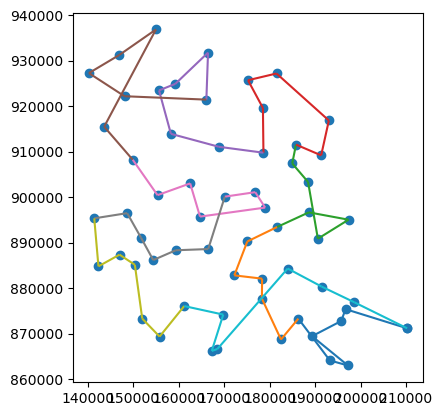

In [19]:
ax = solver.tsp_path.plot(column='Number', categorical=True)
solver.tsp_results.plot(ax=ax)

In [27]:
m = solver.tsp_path.explore(column='Number', tiles='CartoDB Positron', categorical=True)
solver.tsp_results.explore(m=m)

In [75]:
COUNTY = "BERKSHIRE"

cdata = gpd.read_file(f'{COUNTY}_libraries_results.geojson').reset_index()
m = cdata.explore(column='index', tiles='CartoDB Positron', categorical=True)
cdata.explore(m=m)

In [76]:
cdata

,index,NAME,ADDRESS,TOWN,STATE,ZIP,TYPE,ADDRESS_PO,LIBKEY,NETWORK,REGION,DELIVROUTE,WEBSITE,Distance,Cumulative Distance,geometry
0,0,None,None,None,None,None,None,None,None,None,None,None,None,0.000000,0.000000,POINT (210254.866 871175.448)
1,1,"BECKET ATHENAEUM, INC.",3367 MAIN STREET,BECKET,MA,01223,PUBLIC,M_69442_899035,PU-BECKET-ATHENAEUM,MassCat,Western,Optima,http://www.becketathenaeum.org,143542.198704,143542.198704,POINT (69442.158 899034.814)
2,2,PERU LIBRARY,6 WEST MAIN ROAD,PERU,MA,01235,PUBLIC,M_72754_910913,PU-PERU-LIBRARY,None,Western,Optima,None,12331.082750,155873.281454,POINT (72754.228 910912.769)
3,3,HINSDALE PUBLIC LIBRARY,58 MAPLE STREET,HINSDALE,MA,01235,PUBLIC,M_66389_911007,PU-HINSDALE-PUBLIC,MassCat,Western,Optima,http://www.hinsdalelibrary.org,6365.664201,162238.945655,POINT (66389.258 911006.795)
4,4,DALTON FREE PUBLIC LIBRARY,462 MAIN STREET,DALTON,MA,01226,PUBLIC,M_62715_914938,PU-DALTON-FREE,C/WMARS,Western,Optima,http://www.daltonlibrary.org,5380.987070,167619.932725,POINT (62715.094 914938.148)
5,5,WINDSOR FREE PUBLIC LIBRARY,1890 ROUTE 9,WINDSOR,MA,01270,PUBLIC,M_72011_919002,PU-WINDSOR-FREE,None,Western,Optima,http://www.windsormass.com/windsor-public-library,10145.957491,177765.890216,POINT (72011.609 919002.047)
6,6,SAVOY HOLLOW LIBRARY,720 MAIN ROAD,SAVOY,MA,01256,PUBLIC,M_74784_924810,PU-SAVOY-HOLLOW,None,Western,None,None,6427.292599,184193.182814,POINT (74778.944 924803.076)
7,7,FLORIDA FREE PUBLIC LIBRARY,56 NORTH COUNTY ROAD,FLORIDA,MA,01247,PUBLIC,M_73999_939186,PU-FLORIDA-FREE,C/WMARS,Western,Optima,None,14403.653377,198596.836191,POINT (73998.820 939185.588)
8,8,NORTH ADAMS PUBLIC LIBRARY,74 CHURCH STREET,NORTH ADAMS,MA,01247,PUBLIC,M_68185_939879,PU-NADAMS-PUBLIC,C/WMARS,Western,Optima,http://www.naplibrary.com,5854.575453,204451.411644,POINT (68185.483 939879.244)
9,9,DAVID AND JOYCE MILNE PUBLIC LIBRARY,1095 MAIN STREET,WILLIAMSTOWN,MA,01267,PUBLIC,M_59787_941685,PU-WMSTOWN-PUBLIC,C/WMARS,Western,Optima,http://www.milnelibrary.org,8589.862218,213041.273862,POINT (59787.498 941684.675)


## Partition Idea

* For each $k$, the number of ways to partition the set of $n$ towns into two groups of size $k$ and $n-k$ is $n \choose k$, so the total possible ways is $\sum_{k=0}^{\lceil n / 2\rceil}  {n \choose k}$, I think this is equal to $\frac{2^n}{2}=2^{n-1}$


In [25]:
import math

In [37]:
n = 25
sum([math.comb(n, k) for k in range(0, (n+1)//2)])

16777216

In [36]:
2**25/ 2

16777216.0

To divide a set of $n$ elements in three partitions, we need to first choose a two-set partition into $k$ and $n-k$, of which there are $n\choose k$, and then divide one of these into two sets, size $i$ and $k - i$, of which there are $k\choose i$

These numbers are called *Sterling numbers of the second kind*, denoted $\lbrace \frac{n}{k} \rbrace$, and calculated:
$$
\frac{1}{k!}\sum_{i=0}^{k}(-1)^i {k\choose i}(k-i)^n
$$

In [42]:
(-1)**2

1

In [55]:
def sterling_2ndkind(n, k):
    """Returns the number of ways a set of a size n can be partitioned into 
    k separate subsets"""
    
    def sum_term(n, k, i):
        return (-1)**i * math.comb(k, i) * (k - i)**n
    
    summand = sum([ sum_term(n, k, i) for i in range(0, k+1) ])
    return int((1 / math.factorial(k)) * summand)

In [59]:
sterling_2ndkind(64, 3)

572280636706195344702490804224